WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

 Total Force: 0.000045, Simulation time: 0.0013 s / 300.0000 s, dt: 0.001250 s, Elapsed time: 0.09 s
 Total Force: 0.000286, Simulation time: 0.0026 s / 300.0000 s, dt: 0.001312 s, Elapsed time: 0.12 s
 Total Force: 0.000302, Simulation time: 0.0039 s / 300.0000 s, dt: 0.001378 s, Elapsed time: 0.18 s
 Total Force: 0.000312, Simulation time: 0.0054 s / 300.0000 s, dt: 0.001447 s, Elapsed time: 0.20 s
 Total Force: 0.000317, Simulation time: 0.0069 s / 300.0000 s, dt: 0.001519 s, Elapsed time: 0.23 s
 Total Force: 0.000310, Simulation time: 0.0085 s / 300.0000 s, dt: 0.001595 s, Elapsed time: 0.31 s
 Total Force: 0.000449, Simulation time: 0.0102 s / 300.0000 s, dt: 0.001675 s, Elapsed time: 0.33 s
 Total Force: 0.000518, Simulation time: 0.0119 s / 300.0000 s, dt: 0.001759 s, Elapsed time: 0.36 s
 Total Force: 0.000592, Simulation time: 0.0138 s / 300.0000 s, dt: 0.001847 s, Elapsed time: 0.38 s
 Total Force: 0.000717, Simulation time: 0.0157 s / 300.0000 s, dt: 0.001939 s, Elapsed tim

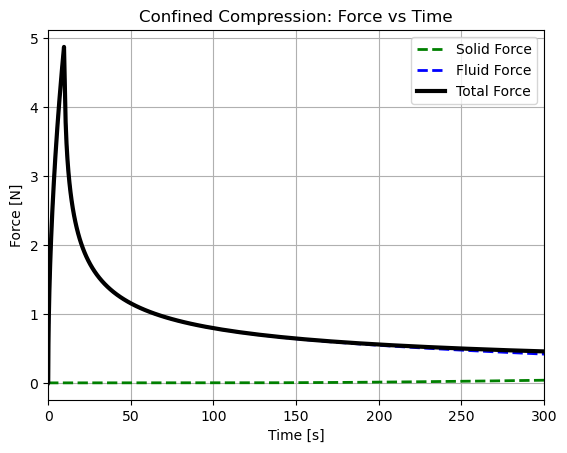

In [5]:
from up_formulation import *
import numpy as np
import time as time
import matplotlib.pyplot as plt
'''
Compression of a Poroelastic cylinder

Confined = True : Confined Compression
Confined = False : Unconfined Compression

'''
Confined = True

R = 3.6 * 10**(-3) # [m] Radius of the cylindrical sample
H = 1e-3 # [m] Height of the cylindrical sample

# Material Properties

nu = 0.2 # Poisson's ratio
G = 2e4
alpha = 1.0 # Biot coefficient
k = 5e-18 # [m^2] Intrinsic Permeability
phi = 0.8 # Porosity
viscosity = 1e-3 # [N s] Fluid viscosity
chi = 1e-10 # [Pa^-1] Fluid Compressibility
rho = 1000 # [kg/m^3] Fluid density
g = -9.81 # [m/s^2] Gravitational acceleration

# Simulation Parameters

dt = 1.25e-3 # [s] Starting Time step size
dt_max = 1000 # [s] Maximum time step size for dynamic time stepping
t_end = 300 # [s] Total simulation time
dt_growth = 1.05 # Growth factor for dynamic time stepping

u_max = H*0.1 # [m] Maximum displacement of the compression
compression_time = 92.6/10 # [s] Time duration for which the compression is applied

# Mesh Parameters
nx = 10 # Number of elements in X direction (radial)
ny = 20 # Number of elements in Y direction (axial)
order = 3 # Polynomial order for the finite element space
grading = 0.95 # Mesh grading parameter, controls bias of elements near the surface
 
# Solver tolerance
tol = 1e-10

# Timing code
t0 = time.time()
time_vals, F_solid, F_fluid = ConfinedCompression(G, nu, viscosity, alpha, phi, k,
     chi, rho, g, dt, dt_max, dt_growth, R, H, u_max , compression_time, t_end, nx,
     ny, grading, order, tol, Confined, DrawResults=True)
t1 = time.time()
print("Simulation time: ", t1 - t0, " seconds", flush=True)
plt.plot(time_vals, F_solid,'--', color='green',lw=2,  label='Solid Force')
plt.plot(time_vals, F_fluid,'--', color='blue',lw=2,  label='Fluid Force')
plt.plot(np.array(time_vals), np.array(F_solid) + np.array(F_fluid), label='Total Force', linestyle='-', color='black', lw=3)
plt.xlabel('Time [s]')
plt.ylabel('Force [N]')
plt.title('Confined Compression: Force vs Time')
plt.legend()
plt.grid()
plt.xlim(0, 300)
print('max force = ' + str(np.max(F_solid + F_fluid)))
plt.show()





